## 基礎套件、設定與角色池各種額度轉換

In [36]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from matplotlib.offsetbox import AnchoredText
import matplotlib.ticker as mtick

# --- Global Visual Configuration ---
sns.set_theme(style="white")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'

# Define professional color palette
COLOR_PMF = '#2c3e50'    # Midnight Blue
COLOR_CDF = '#e74c3c'    # Soft Red
PALETTE_QUANTILES = ['#27ae60', '#f39c12', '#c0392b'] # Emerald, Orange, Pomegranate

# Data directory setup
DATA_DIR = Path('sim_data')

def get_char_sim_path_and_transform_quota(df_path):
    if df_path.exists():
        df_name = pd.read_csv(df_path)
        trials = f"{len(df_name):,}"
        
        # 1. Use .any() to detect if this dataset is for Max Potential simulation (reaches/exceeds 240 pulls)
        if (df_name['num_pulls_for_char'] >= 240).any():
            
            # Floor division returns int64 automatically; no need for .astype(int)
            # Calculates free milestone tokens granted at every 240 pulls
            free_gifts = df_name['num_pulls_for_char'] // 240
            
            # Deduct free milestone tokens from total 6-stars to get actual gacha-pulled count
            actual_pulled_6_star = df_name['up_6_star_char'] - free_gifts + df_name['non_6_star_char']
            
            # 1.1 Weapon Quota (Max Potential Branch)
            # Earned from actual gacha pulls only; free milestone tokens do not yield weapon quota
            df_name['weapon_quota'] = actual_pulled_6_star * 2000 + \
                                      df_name['5_star_char'] * 200 + \
                                      df_name['4_star_char'] * 20
            
            # 1.2 Red Quota (Max Potential Branch - Guarantee/Redemption)
            # Rule: 2nd+ 6* gives 50; 2nd+ 5* gives 10; 4* gives 0
            # Excludes free milestone tokens from receiving duplicate Red Certificates
            df_name['red_quota'] = (actual_pulled_6_star - 1).clip(lower=0) * 50 + \
                                   (df_name['5_star_char']).clip(lower=0) * 10

            # 1.3 Blue Quota (Max Potential Branch - Integrated Integration Quota)
            # Based on baseline assumption: 4* and 5* are already at Max Potential prior to this pull session
            # Conversion rates: Max Pot 5* -> 20 Blue; Max Pot 4* -> 5 Blue
            df_name['blue_quota'] = (df_name['5_star_char']).clip(lower=0) * 20 + \
                                    (df_name['4_star_char']).clip(lower=0) * 5
            
            return df_name, trials
        
        # --- Else Branch: First-copy Acquisition (Below 240 pulls, no milestone gift triggered) ---
        else:
            # 2.1 Weapon Quota (First-copy Branch - Standard conversion based on total pulls)
            df_name['weapon_quota'] = (df_name['up_6_star_char'] + df_name['non_6_star_char']) * 2000 + \
                                      df_name['5_star_char'] * 200 + \
                                      df_name['4_star_char'] * 20
            
            # 2.2 Red Quota (First-copy Branch - Guarantee/Redemption)
            df_name['red_quota'] = (df_name['up_6_star_char'] + df_name['non_6_star_char'] - 1).clip(lower=0) * 50 + \
                                   (df_name['5_star_char']).clip(lower=0) * 10

            # 2.3 Blue Quota (First-copy Branch - Integrated Integration Quota)
            df_name['blue_quota'] = (df_name['5_star_char']).clip(lower=0) * 20 + \
                                    (df_name['4_star_char']).clip(lower=0) * 5
            return df_name, trials

    return None, "0"


## 首次獲得限定角色模擬結果之統計與視覺化圖表

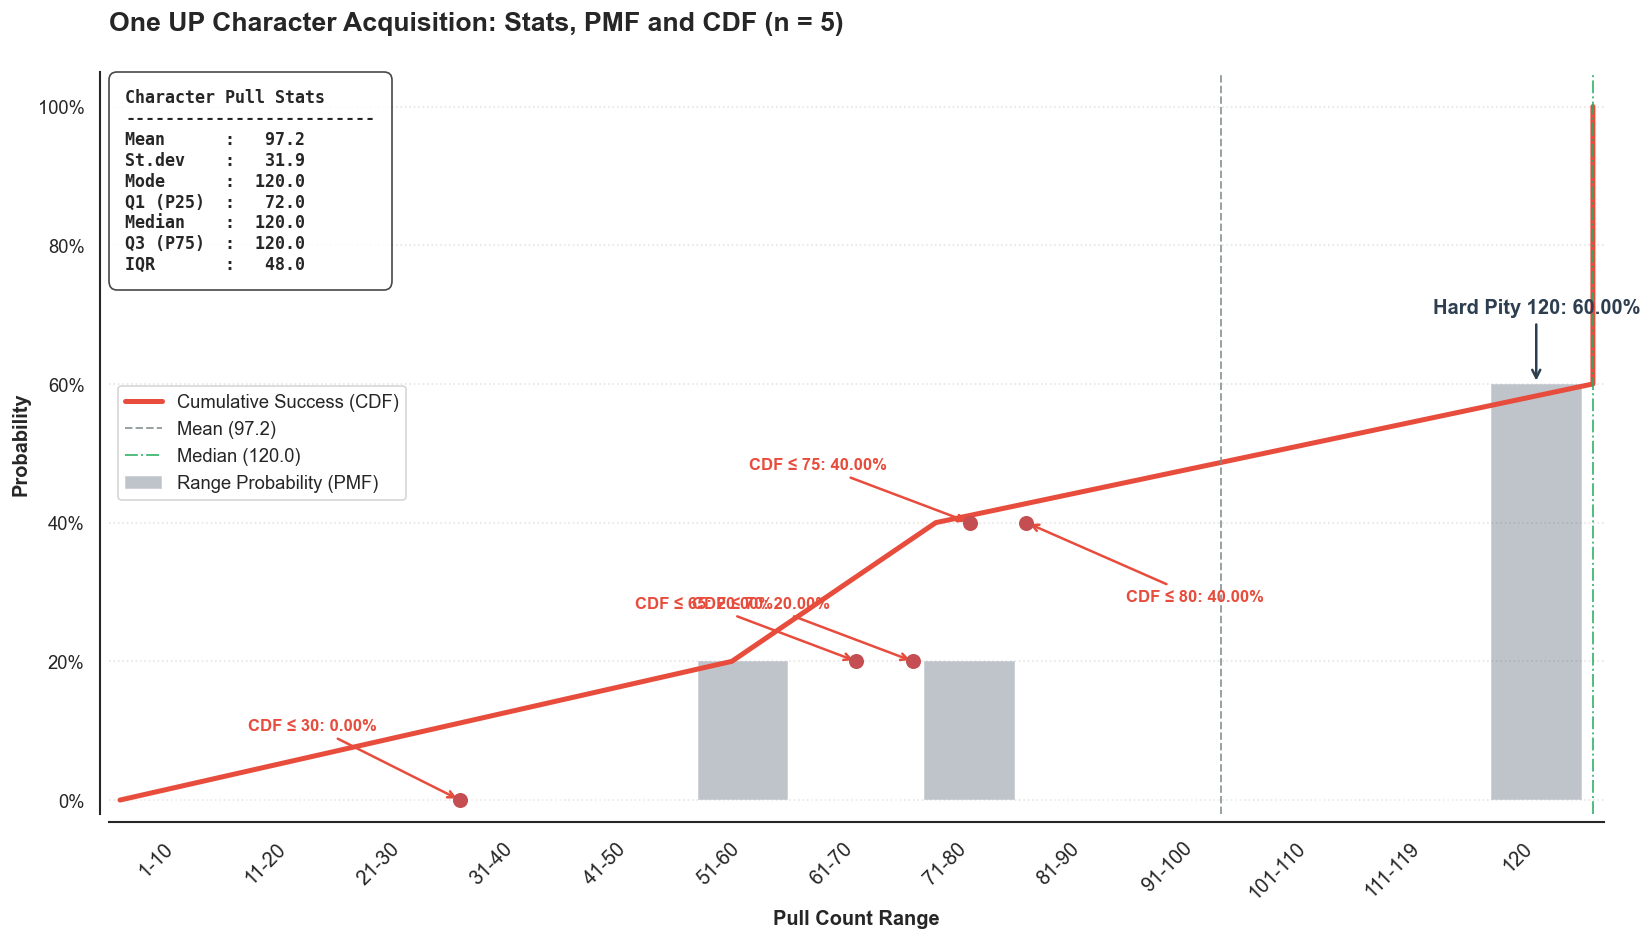

=== Layered Insight Analysis ===
1. Ratio WITHIN 120-pull wall (1 UP + 1 Non-UP at exactly 120 pulls): 0.00%
2. Ratio ACROSS entire dataset (1 UP + 1 Non-UP at exactly 120 pulls): 0.00%
3. Ratio of SUFFOCATION ZONE (101-120 pulls with exactly 1 UP + 1 Non-UP) across entire dataset: 0.00%


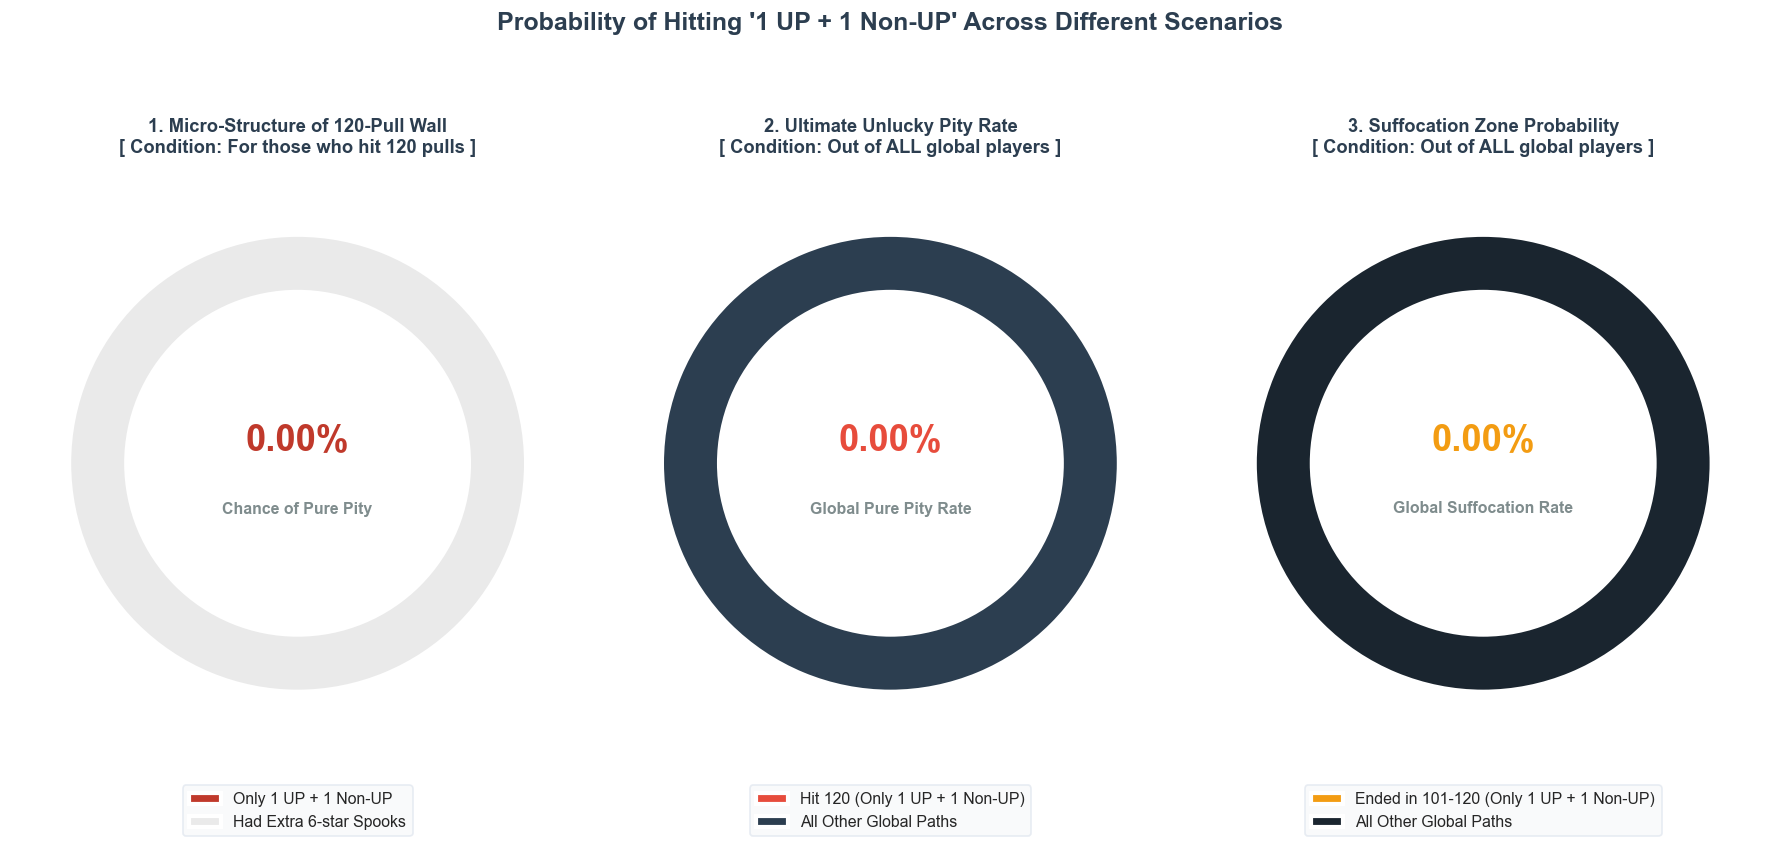

In [37]:
# --- Load and Apply Endgame Conversion Rules ---
single_char_path = DATA_DIR / 'sim_char_single.csv'
df_char, trials = get_char_sim_path_and_transform_quota(single_char_path)

# --- 1. Data Categorization & Cumulative Probability Processing ---
pulls_data = df_char['num_pulls_for_char']

# Define custom boundaries to isolate the final 120th pull
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 119, 120]

# Build custom labels matching the custom bins
labels = []
for i in range(len(bins)-1):
    if bins[i+1] == 120:
        labels.append("120") # Isolated hard pity wall
    else:
        labels.append(f"{bins[i]+1}-{bins[i+1]}")

# Categorize data into corresponding ranges using pd.cut
df_char['range_cat'] = pd.cut(pulls_data, bins=bins, labels=labels)

# Calculate percentage for each range (PMF)
pmf_values = df_char['range_cat'].value_counts(normalize=True).sort_index() * 100

# --- 2. Plotting Settings ---
fig, ax = plt.subplots(figsize=(14, 8))
x_pos = np.arange(len(labels))

# 2.1 PMF Bar Chart (Represents range probability)
ax.bar(x_pos, pmf_values, color=COLOR_PMF, alpha=0.3, edgecolor='white', linewidth=1, label='Range Probability (PMF)')

# 2.2 CDF Cumulative Curve with Non-uniform Axis Mapping (Using Interpolation)
sorted_data = np.sort(pulls_data)
cdf_x_raw = np.insert(sorted_data, 0, 0)
cdf_y_raw = np.insert(np.arange(1, len(sorted_data) + 1) / float(len(sorted_data)) * 100, 0, 0)

# Build a mapping anchor table to translate real pull counts to categorical x-coordinates
# Real pull counts at bin boundaries: [0, 10, 20, ..., 110, 119, 120]
# map to bar chart coordinates:      [-0.5, 0.5, 1.5, ..., 10.5, 11.5, 12.5]
xp_anchors = np.array(bins)
fp_anchors = np.arange(len(bins)) - 0.5

# Perform linear interpolation to get a perfectly aligned CDF curve
cdf_x_mapped = np.interp(cdf_x_raw, xp_anchors, fp_anchors)
ax.plot(cdf_x_mapped, cdf_y_raw, color=COLOR_CDF, linewidth=3, label='Cumulative Success (CDF)')

# 2.3 Added Professional Visual Anchors: Mean and Median Vlines
mean_val = pulls_data.mean()
median_val = pulls_data.median()

# Map Mean and Median dynamically using our non-uniform anchor system
mean_x_mapped = np.interp(mean_val, xp_anchors, fp_anchors)
median_x_mapped = np.interp(median_val, xp_anchors, fp_anchors)

ax.axvline(mean_x_mapped, color='#7f8c8d', linestyle='--', linewidth=1.2, alpha=0.8, label=f'Mean ({mean_val:.1f})')
ax.axvline(median_x_mapped, color='#27ae60', linestyle='-.', linewidth=1.2, alpha=0.8, label=f'Median ({median_val:.1f})')

# 2.4 Statistical Parameters (Top-Left Box)
stats = {
    'Mean': mean_val,
    'St.dev': pulls_data.std(),
    'Mode': pulls_data.mode()[0],
    'Q1 (P25)': pulls_data.quantile(0.25),
    'Median': median_val,
    'Q3 (P75)': pulls_data.quantile(0.75),
    'IQR': pulls_data.quantile(0.75) - pulls_data.quantile(0.25)
}
stats_text = "\n".join([f"{k:10}: {v:>6.1f}" for k, v in stats.items()])
at = AnchoredText(f"Character Pull Stats\n{'-'*25}\n{stats_text}",
                  prop=dict(size=10, family='monospace', fontweight='bold'), 
                  frameon=True, loc='upper left', pad=0.5)
at.patch.set_boxstyle("round,pad=0.5")
at.patch.set_alpha(0.8)
ax.add_artist(at)

# 2.5 Specific Annotations
# (1) PMF Annotation: Pinpointed to look at the custom 120 hard pity bar (the 13th bar -> index 12)
target_idx_final = 12 
val_120 = pmf_values.iloc[target_idx_final]
ax.annotate(f'Hard Pity 120: {val_120:.2f}%', 
            xy=(target_idx_final, val_120), 
            xytext=(0, 40), textcoords="offset points", 
            arrowprops=dict(arrowstyle='->', color=COLOR_PMF, lw=1.5),
            ha='center', va='bottom', fontweight='bold', color=COLOR_PMF)

# (2) CDF Annotation List [30, 65, 80] using offset points to guarantee bulletproof arrow directions
cdf_targets = [30, 65, 70, 75, 80]

for target in cdf_targets:
    cdf_val = (pulls_data <= target).mean() * 100
    
    # Map marker dots perfectly onto the curve using the interpolation map
    marker_x = np.interp(target, xp_anchors, fp_anchors)
    ax.plot(marker_x, cdf_val, 'ro', markersize=8, zorder=5)
    
    # Custom pixel-offset layout based on the target location
    if target == 30 :
        x_pt, y_pt = -50, 40
        ha_dir, va_dir = 'right', 'bottom'
    elif target == 65 or target == 70 or target == 75:
        # Pushed to Top-Left because 65 is likely on the super steep soft-pity cliff
        x_pt, y_pt = -50, 30
        ha_dir, va_dir = 'right', 'bottom'
    else:
        # Target 80: Bottom-Right to use open space after the cliff
        x_pt, y_pt = 60, -40
        ha_dir, va_dir = 'left', 'top'
        
    ax.annotate(f'CDF ≤ {target}: {cdf_val:.2f}%', 
                xy=(marker_x, cdf_val), 
                xytext=(x_pt, y_pt), textcoords="offset points",
                arrowprops=dict(arrowstyle='->', color=COLOR_CDF, lw=1.5),
                fontweight='bold', color=COLOR_CDF, fontsize=10,
                ha=ha_dir, va=va_dir)

# 2.6 Formatting & Detail Optimization
plt.title(f'One UP Character Acquisition: Stats, PMF and CDF (n = {trials})', fontsize=16, fontweight='bold', loc='left', pad=25)
ax.set_xlabel('Pull Count Range', fontsize=12, fontweight='bold')
ax.set_ylabel('Probability', fontsize=12, fontweight='bold')

ax.set_ylim(-2, 105)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

# Set limits covering exactly all 13 custom ranges
ax.set_xlim(-0.6, len(labels) - 0.4) 

# Fixed legend location
ax.legend(loc='center left', frameon=True)

# Disable trim to maintain unbroken axis line on the bottom-left corner
sns.despine(offset=5, trim=False)

# Apply rotated ticks beautifully (rotated 45 deg because we have 13 custom text labels now)
ax.set_xticks(x_pos)
plt.xticks(x_pos, labels, rotation=45, fontsize=12, ha='right')

plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

# =========================================================================
# 1. Stratified Filtering & Precise Metric Calculations
# =========================================================================
# Core condition A: Ultimate Unlucky Target (Exactly 120 pulls, 1 UP, 1 Non-UP Only)
unlucky_count = len(df_char.loc[
    (df_char['num_pulls_for_char'] == 120) & 
    (df_char['up_6_star_char'] == 1) & 
    (df_char['non_6_star_char'] == 1)
])

# Core condition B: Suffocation Zone Target (101 to 120 pulls, 1 UP, 1 Non-UP Only)
suffocation_zone_count = len(df_char.loc[
    (df_char['num_pulls_for_char'] >= 101) & 
    (df_char['num_pulls_for_char'] <= 120) & 
    (df_char['up_6_star_char'] == 1) & 
    (df_char['non_6_star_char'] == 1)
])

# Base Denominators
total_120_players = len(df_char.loc[df_char['num_pulls_for_char'] == 120])
total_all_players = len(df_char)

# Calculate dynamic ratios exactly matching your logic
ratio_within_120_wall = (unlucky_count / total_120_players) * 100 if total_120_players > 0 else 0
ratio_across_all_data = (unlucky_count / total_all_players) * 100 if total_all_players > 0 else 0
ratio_suffocation_zone = (suffocation_zone_count / total_all_players) * 100 if total_all_players > 0 else 0

print(f"=== Layered Insight Analysis ===")
print(f"1. Ratio WITHIN 120-pull wall (1 UP + 1 Non-UP at exactly 120 pulls): {ratio_within_120_wall:.2f}%")
print(f"2. Ratio ACROSS entire dataset (1 UP + 1 Non-UP at exactly 120 pulls): {ratio_across_all_data:.2f}%")
print(f"3. Ratio of SUFFOCATION ZONE (101-120 pulls with exactly 1 UP + 1 Non-UP) across entire dataset: {ratio_suffocation_zone:.2f}%")

# =========================================================================
# 2. Straightforward Text Mapping (Intuitive Probability Focus)
# =========================================================================
# Chart 1: Given you hit 120 pulls, what is the chance of having ZERO extra 6-stars?
data_p1 = [ratio_within_120_wall, 100 - ratio_within_120_wall]
colors_p1 = ['#c0392b', '#eaeaea'] 
labels_p1 = ['Only 1 UP + 1 Non-UP', 'Had Extra 6-star Spooks']

# Chart 2: Out of ALL players, what is the chance of hitting 120 pulls with ZERO extra 6-stars?
data_p2 = [ratio_across_all_data, 100 - ratio_across_all_data]
colors_p2 = ['#e74c3c', '#2c3e50'] 
labels_p2 = ['Hit 120 (Only 1 UP + 1 Non-UP)', 'All Other Global Paths']

# Chart 3: Out of ALL players, what is the chance of ending in 101-120 pulls with ZERO extra 6-stars?
data_p3 = [ratio_suffocation_zone, 100 - ratio_suffocation_zone]
colors_p3 = ['#f39c12', '#1a252f'] 
labels_p3 = ['Ended in 101-120 (Only 1 UP + 1 Non-UP)', 'All Other Global Paths']

plot_configs = [
    (data_p1, colors_p1, labels_p1, ratio_within_120_wall, "Chance of Pure Pity"),
    (data_p2, colors_p2, labels_p2, ratio_across_all_data, "Global Pure Pity Rate"),
    (data_p3, colors_p3, labels_p3, ratio_suffocation_zone, "Global Suffocation Rate")
]

# Using titles as the descriptive framework so the chart speaks for itself
titles = [
    "1. Micro-Structure of 120-Pull Wall\n[ Condition: For those who hit 120 pulls ]",
    "2. Ultimate Unlucky Pity Rate\n[ Condition: Out of ALL global players ]",
    "3. Suffocation Zone Probability\n[ Condition: Out of ALL global players ]"
]

# =========================================================================
# 3. Canvas Blueprint & Intuitive Donut Render Engine
# =========================================================================
fig, axs = plt.subplots(1, 3, figsize=(15, 6.5), dpi=120)
donut_width = 0.25  

for i, (data, colors, legend_labels, target_metric, center_label) in enumerate(plot_configs):
    wedges, _ = axs[i].pie(
        data, 
        colors=colors, 
        startangle=90,
        counterclock=False,  
        wedgeprops=dict(width=donut_width, edgecolor='w', linewidth=2.5)
    )
    
    # --- Center KPI Metrics Text Injection ---
    axs[i].text(
        0, 0.1, f"{target_metric:.2f}%", 
        ha='center', va='center', 
        fontsize=22, weight='bold', color=colors[0]
    )
    axs[i].text(
        0, -0.2, center_label, 
        ha='center', va='center', 
        fontsize=9.5, weight='bold', color='#7f8c8d'
    )
    
    # --- Simplified Legend Layout Positioning ---
    axs[i].legend(
        wedges, legend_labels,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.05),  
        frameon=True,
        facecolor='#f8f9fa',
        edgecolor='#e2e8f0',
        fontsize=9.5
    )
    
    axs[i].set_title(titles[i], fontsize=11, weight='bold', color='#2c3e50', pad=15)

plt.suptitle("Probability of Hitting '1 UP + 1 Non-UP' Across Different Scenarios", fontsize=15, weight='bold', color='#2c3e50', y=1.05)
plt.tight_layout()
plt.show()

## 滿潛限定角色模擬結果之統計與視覺化圖表

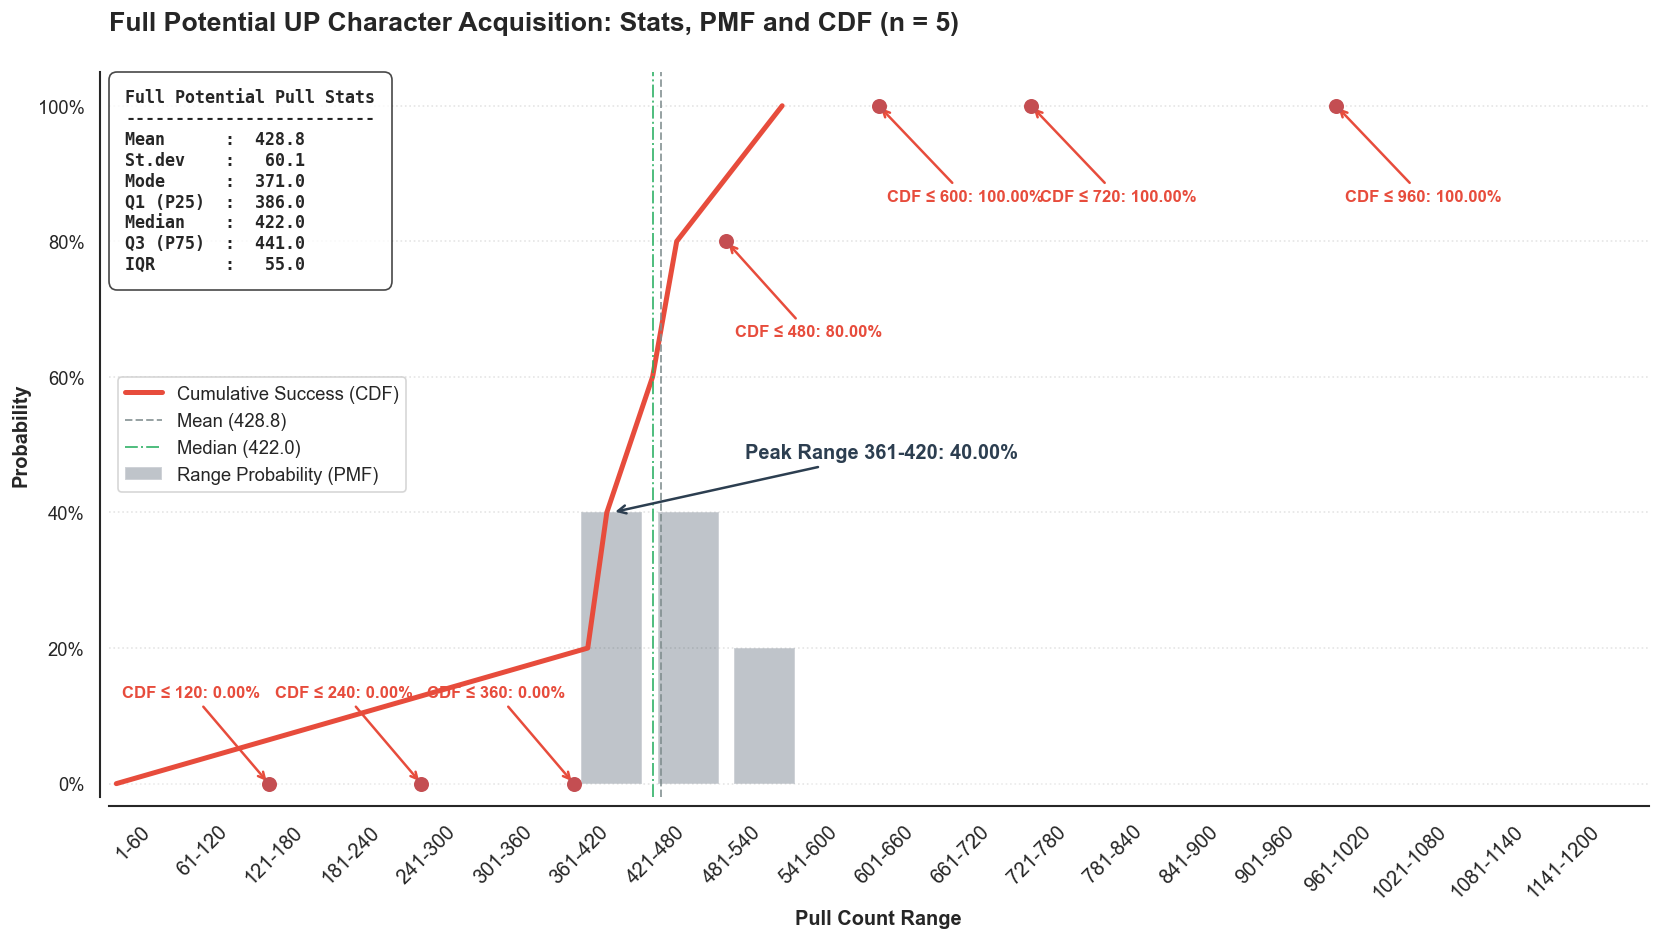

In [38]:
# --- Load and Apply Endgame Conversion Rules ---
FP_char_path = DATA_DIR / 'sim_char_full_potential.csv'
df_FPchar, trials = get_char_sim_path_and_transform_quota(FP_char_path)

# --- 1. Data Categorization & Cumulative Probability Processing ---
pulls_data = df_FPchar['num_pulls_for_char']

# Define boundaries and labels for 1-60, 61-120, ..., 1141-1200 (20 intervals)
bins = np.arange(0, 1201, 60) 
labels = [f"{i+1}-{i+60}" for i in bins[:-1]]

# Categorize data into corresponding 60-pull ranges using pd.cut
df_FPchar['range_cat'] = pd.cut(pulls_data, bins=bins, labels=labels)

# Calculate percentage for each range (PMF)
pmf_values = df_FPchar['range_cat'].value_counts(normalize=True).sort_index() * 100

# --- 2. Plotting Settings ---
fig, ax = plt.subplots(figsize=(14, 8))
x_pos = np.arange(len(labels))

# 2.1 PMF Bar Chart (Represents range probability)
ax.bar(x_pos, pmf_values, color=COLOR_PMF, alpha=0.3, edgecolor='white', linewidth=1, label='Range Probability (PMF)')

# 2.2 CDF Cumulative Curve (Starting from origin)
sorted_data = np.sort(pulls_data)
cdf_x_raw = np.insert(sorted_data, 0, 0)
cdf_y_raw = np.insert(np.arange(1, len(sorted_data) + 1) / float(len(sorted_data)) * 100, 0, 0)

# Map raw pull counts to categorical axis coordinates
cdf_x_mapped = (cdf_x_raw / 60.0) - 0.5
ax.plot(cdf_x_mapped, cdf_y_raw, color=COLOR_CDF, linewidth=3, label='Cumulative Success (CDF)')

# 2.3 Added Professional Visual Anchors: Mean and Median Vlines
mean_val = pulls_data.mean()
median_val = pulls_data.median()

# Map these exact pull counts onto our categorical X-axis template
mean_x_mapped = (mean_val / 60.0) - 0.5
median_x_mapped = (median_val / 60.0) - 0.5

# Plot vertical dashed lines for central tendency markers
ax.axvline(mean_x_mapped, color='#7f8c8d', linestyle='--', linewidth=1.2, alpha=0.8, label=f'Mean ({mean_val:.1f})')
ax.axvline(median_x_mapped, color='#27ae60', linestyle='-.', linewidth=1.2, alpha=0.8, label=f'Median ({median_val:.1f})')

# 2.4 Statistical Parameters (Top-Left Box) - Added IQR for better dispersion context
stats = {
    'Mean': mean_val,
    'St.dev': pulls_data.std(),
    'Mode': pulls_data.mode()[0],
    'Q1 (P25)': pulls_data.quantile(0.25),
    'Median': median_val,
    'Q3 (P75)': pulls_data.quantile(0.75),
    'IQR': pulls_data.quantile(0.75) - pulls_data.quantile(0.25)
}
stats_text = "\n".join([f"{k:10}: {v:>6.1f}" for k, v in stats.items()])
at = AnchoredText(f"Full Potential Pull Stats\n{'-'*25}\n{stats_text}",
                  prop=dict(size=10, family='monospace', fontweight='bold'), 
                  frameon=True, loc='upper left', pad=0.5)
at.patch.set_boxstyle("round,pad=0.5")
at.patch.set_alpha(0.8)
ax.add_artist(at)

# 2.5 Specific Annotations
# (1) PMF Annotation: Peak Range
target_idx_peak = pmf_values.argmax()
val_peak = pmf_values.iloc[target_idx_peak]
label_peak = labels[target_idx_peak]

ax.annotate(f'Peak Range {label_peak}: {val_peak:.2f}%', 
            xy=(target_idx_peak, val_peak), 
            xytext=(80, 30), textcoords="offset points",
            arrowprops=dict(arrowstyle='->', color=COLOR_PMF, lw=1.5),
            ha='left', va='bottom', fontweight='bold', color=COLOR_PMF)

# (2) CDF Annotation List (Target 480 now successfully merged into the bottom-right group)
cdf_targets = [120, 240, 360, 480, 600, 720, 960]

for target in cdf_targets:
    cdf_val = (pulls_data <= target).mean() * 100
    marker_x = (target / 60.0) - 0.5
    ax.plot(marker_x, cdf_val, 'ro', markersize=8, zorder=5)
    
    # Clean two-way branching logic based on your request
    if target == 120 or target == 240 or target == 360:
        # Strictly Top-Left
        x_pt, y_pt = -5, 50
        ha_dir, va_dir = 'right', 'bottom'
    else:
        # Targets 480, 600, 720, 960: Strictly Bottom-Right to capture open real estate
        x_pt, y_pt = 5, -50
        ha_dir, va_dir = 'left', 'top'
        
    if (99.9 <= cdf_val < 100) or (0 < cdf_val <= 0.1):
        precision = 4
    else:
        precision = 2
        
    ax.annotate(f'CDF ≤ {target}: {cdf_val:.{precision}f}%', 
                xy=(marker_x, cdf_val), 
                xytext=(x_pt, y_pt), textcoords="offset points",
                arrowprops=dict(arrowstyle='->', color=COLOR_CDF, lw=1.5),
                fontweight='bold', color=COLOR_CDF, fontsize=10,
                ha=ha_dir, va=va_dir)

# 2.6 Formatting & Detail Optimization
plt.title(f'Full Potential UP Character Acquisition: Stats, PMF and CDF (n = {trials})', fontsize=16, fontweight='bold', loc='left', pad=25)
ax.set_xlabel('Pull Count Range', fontsize=12, fontweight='bold')
ax.set_ylabel('Probability', fontsize=12, fontweight='bold')

ax.set_ylim(-2, 105)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlim(-0.6, len(labels) - 0.4) 

# Fixed legend location
ax.legend(loc='center left', frameon=True)

# Maintain unbroken axis line on the bottom-left corner
sns.despine(offset=5, trim=False)

# Re-apply rotated ticks beautifully
ax.set_xticks(x_pos)
plt.xticks(x_pos, labels, rotation=45, fontsize=12, ha='right')

plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

## 武庫配額獲取與武器池抽數轉換模擬結果之統計與視覺化圖表

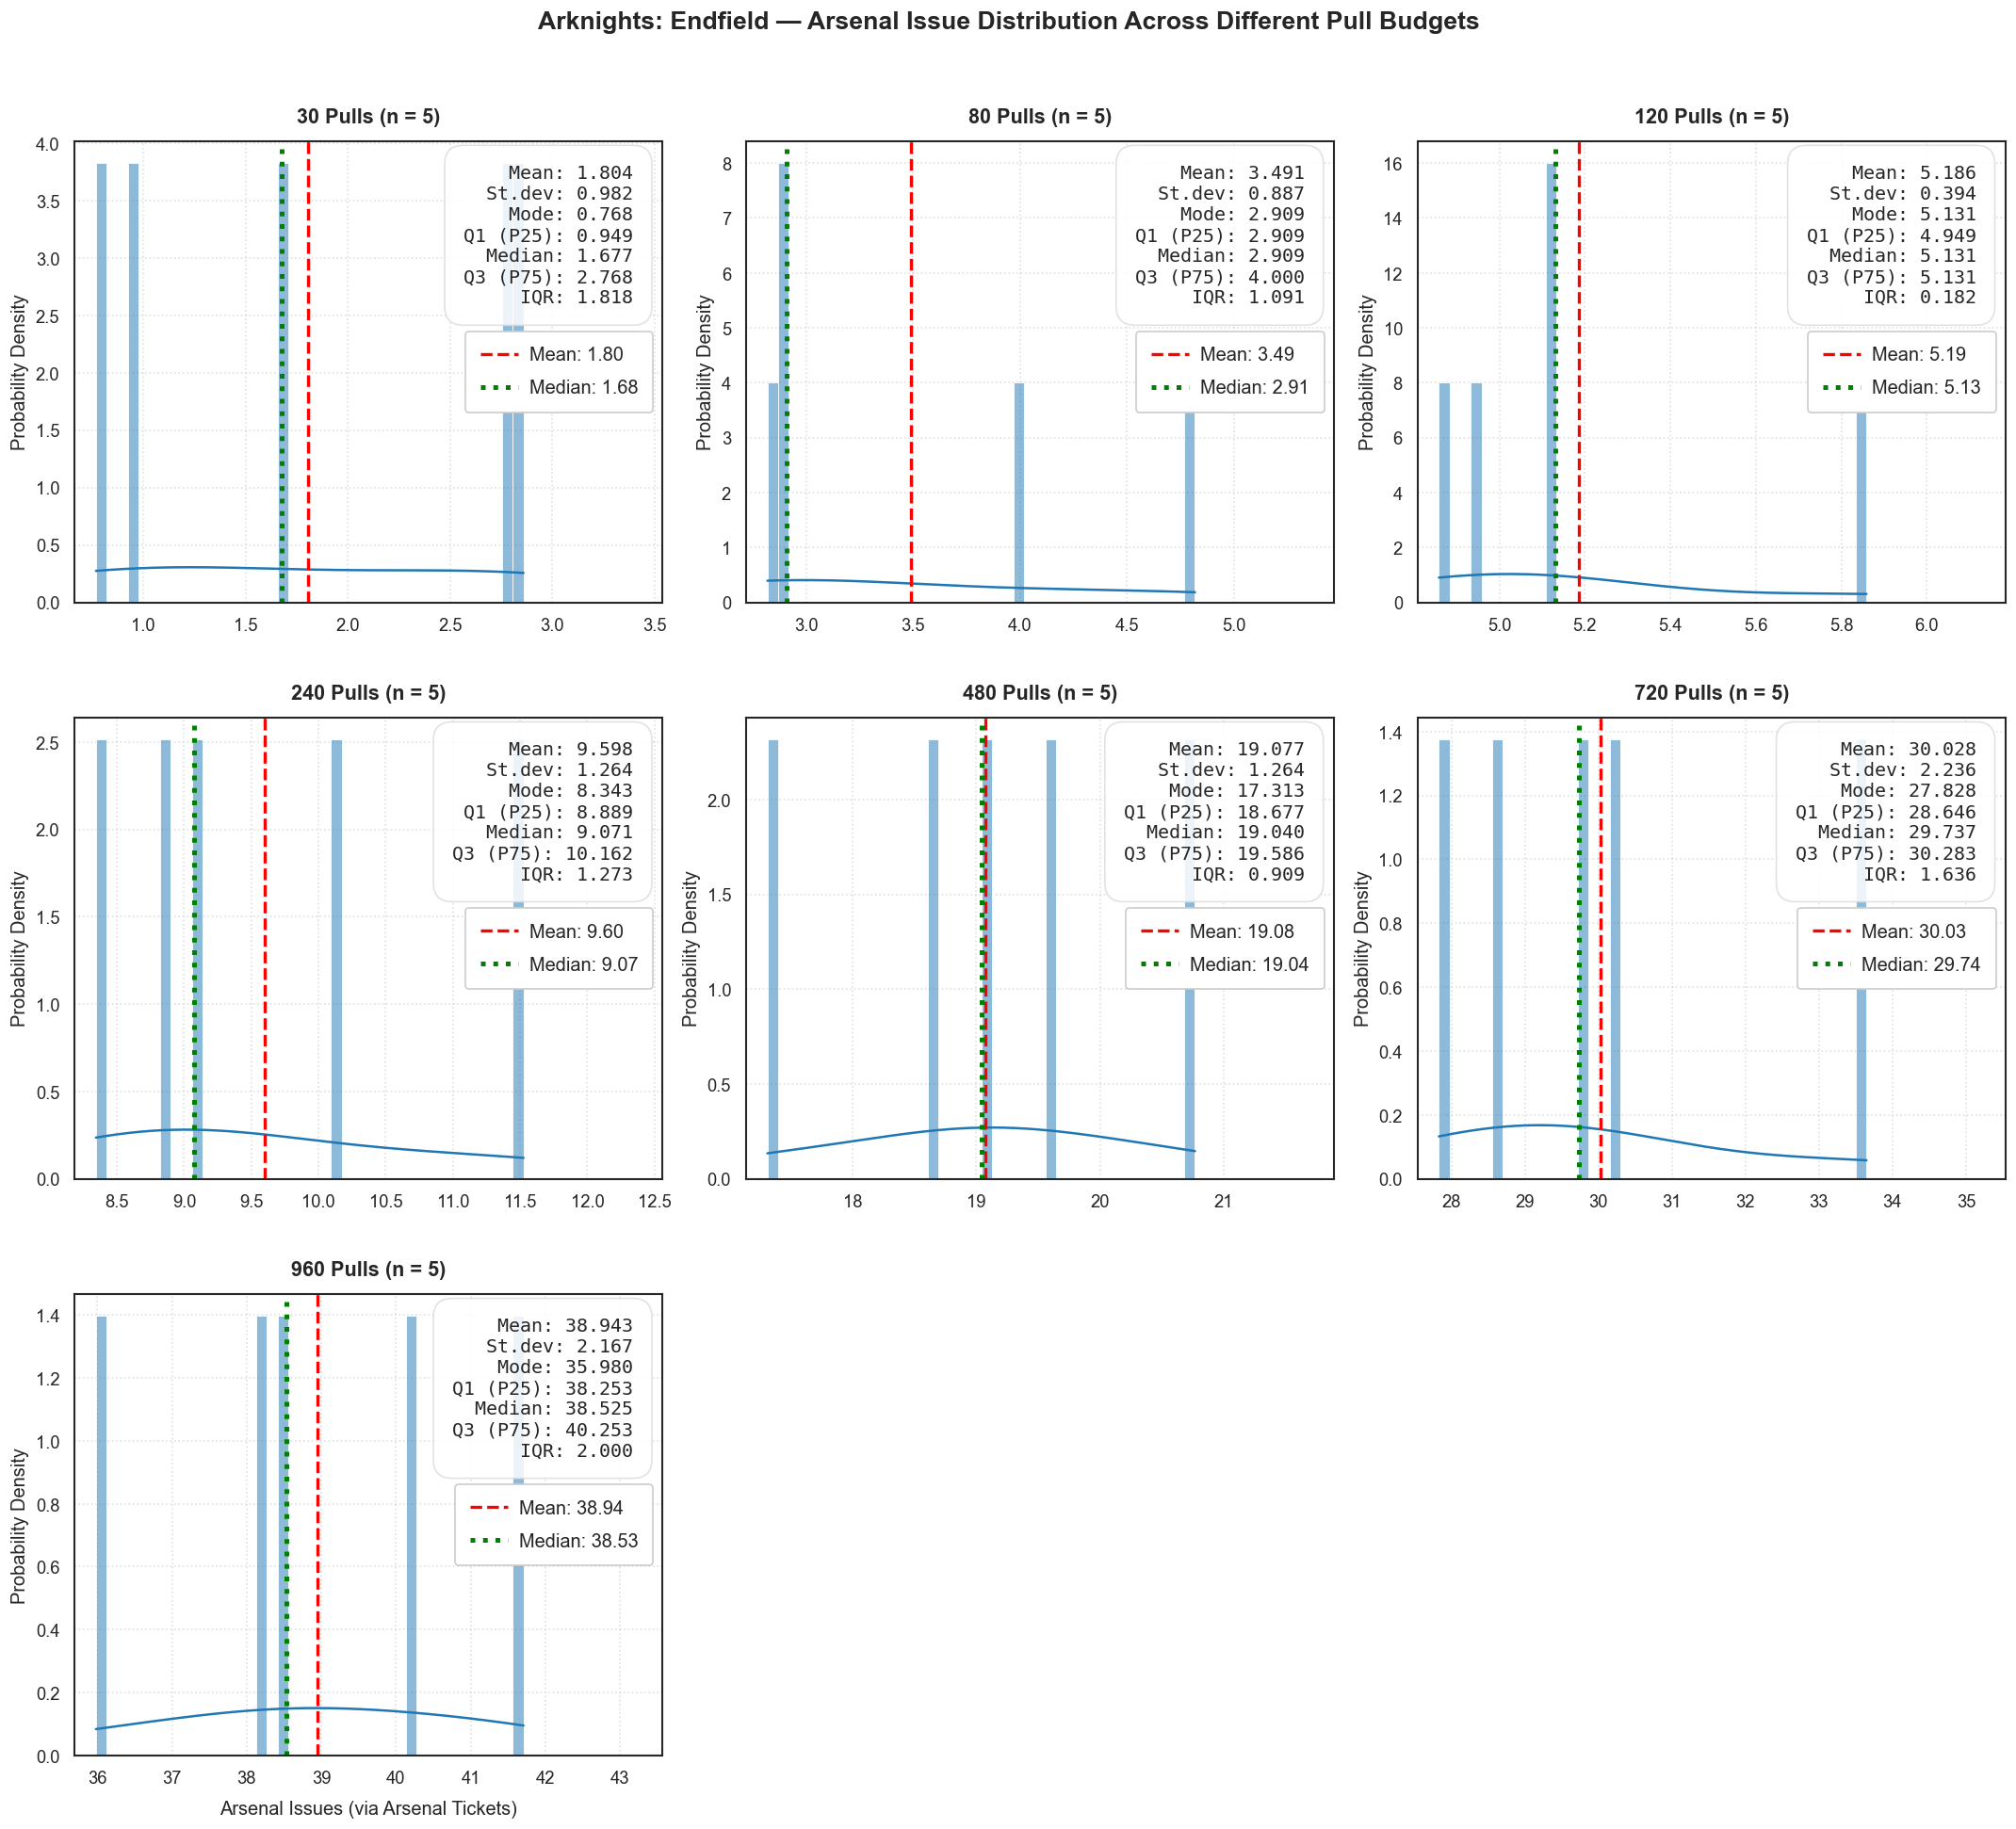

In [39]:
# --- 1. Single Source of Truth Configuration ---
# Anyone can freely add '30' or other nodes here; layout adapts automatically.
pull_nodes = [30, 80, 120, 240, 480, 720, 960]

# Grid Layout Calculation: fixed to 3 columns, rows scale dynamically
cols = 3
rows = math.ceil(len(pull_nodes) / cols)

# Initialize dynamic canvas grid based on computed dimensions
fig, axes = plt.subplots(
    nrows=rows, ncols=cols, figsize=(cols * 6, rows * 5.5), sharey=False
)

# Flatten axes array for safe 1D iteration across any grid configuration
axes_flat = axes.flatten() if len(pull_nodes) > 1 else [axes]

# --- 2. Iterative Pipeline Loop ---
for i, nodes in enumerate(pull_nodes):
    ax = axes_flat[i]
    file_path = DATA_DIR / f"sim_fixed_{nodes}_pulls.csv"

    # Defensive check if the CSV node is missing
    if not file_path.exists():
        ax.text(
            0.5,
            0.5,
            f"Missing Simulation Data\nNode: {nodes} Pulls",
            ha="center",
            va="center",
            color="red",
            fontsize=12,
        )
        ax.set_axis_off()
        continue

    # Load and apply endgame conversion rules via your existing pipeline helper
    df_fixed, trials = get_char_sim_path_and_transform_quota(file_path)

    # Convert weapon quota data to Arsenal Issues (Single Source of Truth transformation)
    pulls_data = df_fixed["weapon_quota"] / 1980

    # Calculate specific statistical indicators
    mean_val = pulls_data.mean()
    median_val = pulls_data.median()
    mode_series = pulls_data.mode()
    mode_val = mode_series[0] if not mode_series.empty else mean_val
    q1 = pulls_data.quantile(0.25)
    q3 = pulls_data.quantile(0.75)
    iqr = q3 - q1
    std_val = pulls_data.std()

    # Draw histogram and KDE line using your professional styling
    sns.histplot(
        pulls_data,
        kde=True,
        ax=ax,
        color="#1f77b4",
        edgecolor="white",
        linewidth=0.5,
        stat="density",
        bins=40,
    )

    # Draw prominent reference lines (Mean: 2.0 dashed, Median: 3.0 dotted)
    ax.axvline(
        mean_val,
        color="red",
        linestyle="--",
        linewidth=2.0,
        label=f"Mean: {mean_val:.2f}",
    )
    ax.axvline(
        median_val,
        color="green",
        linestyle=":",
        linewidth=3.0,
        label=f"Median: {median_val:.2f}",
    )

    # --- 3. Dynamic X-axis Limit Tuning (Optimized for Center Right Legend) ---
    x_min, x_max = ax.get_xlim()
    ax.set_xlim(x_min, x_max + (x_max - x_min) * 0.25)

    # --- 4. Construct Descriptive Statistical Text Box ---
    stats_text = (
        f"Mean: {mean_val:.3f}\n"
        f"St.dev: {std_val:.3f}\n"
        f"Mode: {mode_val:.3f}\n"
        f"Q1 (P25): {q1:.3f}\n"
        f"Median: {median_val:.3f}\n"
        f"Q3 (P75): {q3:.3f}\n"
        f"IQR: {iqr:.3f}"
    )

    ax.text(
        0.95,
        0.95,
        stats_text,
        transform=ax.transAxes,
        fontsize=12,
        fontfamily="monospace",
        verticalalignment="top",
        horizontalalignment="right",
        bbox=dict(
            boxstyle="round,pad=1", facecolor="white", alpha=0.85, edgecolor="#dddddd"
        ),
    )

    # --- 5. Axes and Subplot Aesthetics Fine-Tuning ---
    ax.set_title(
        f"{nodes} Pulls (n = {len(pulls_data):,})", fontsize=13, fontweight="bold", pad=12
    )

    # Clean Layout: Dynamically only show X-label on the bottom row of active plots
    if i >= (rows - 1) * cols:
        ax.set_xlabel(
            "Arsenal Issues (via Arsenal Tickets)", fontsize=12, labelpad=8
        )
    else:
        ax.set_xlabel("", fontsize=10)

    ax.set_ylabel("Probability Density", fontsize=12)
    ax.grid(True, linestyle=":", alpha=0.6)

    # Set legend to center right with a slightly transparent frame
    ax.legend(
        loc="center right",
        fontsize=12,
        framealpha=1,
        borderpad=0.8,
        labelspacing=0.8,
        handletextpad=0.6,
    )

# --- 6. Clean up redundant empty subplots if the grid isn't perfectly filled ---
for empty_idx in range(len(pull_nodes), len(axes_flat)):
    axes_flat[empty_idx].set_axis_off()

# --- 7. Global Layout Optimization and Rendering ---
plt.suptitle(
    "Arknights: Endfield — Arsenal Issue Distribution Across Different Pull Budgets",
    fontsize=16,
    fontweight="bold",
    y=0.98,
)
plt.tight_layout()
plt.subplots_adjust(top=0.91, hspace=0.25)
plt.show()

## 首次獲得機率提升武器模擬結果之統計與視覺化圖表

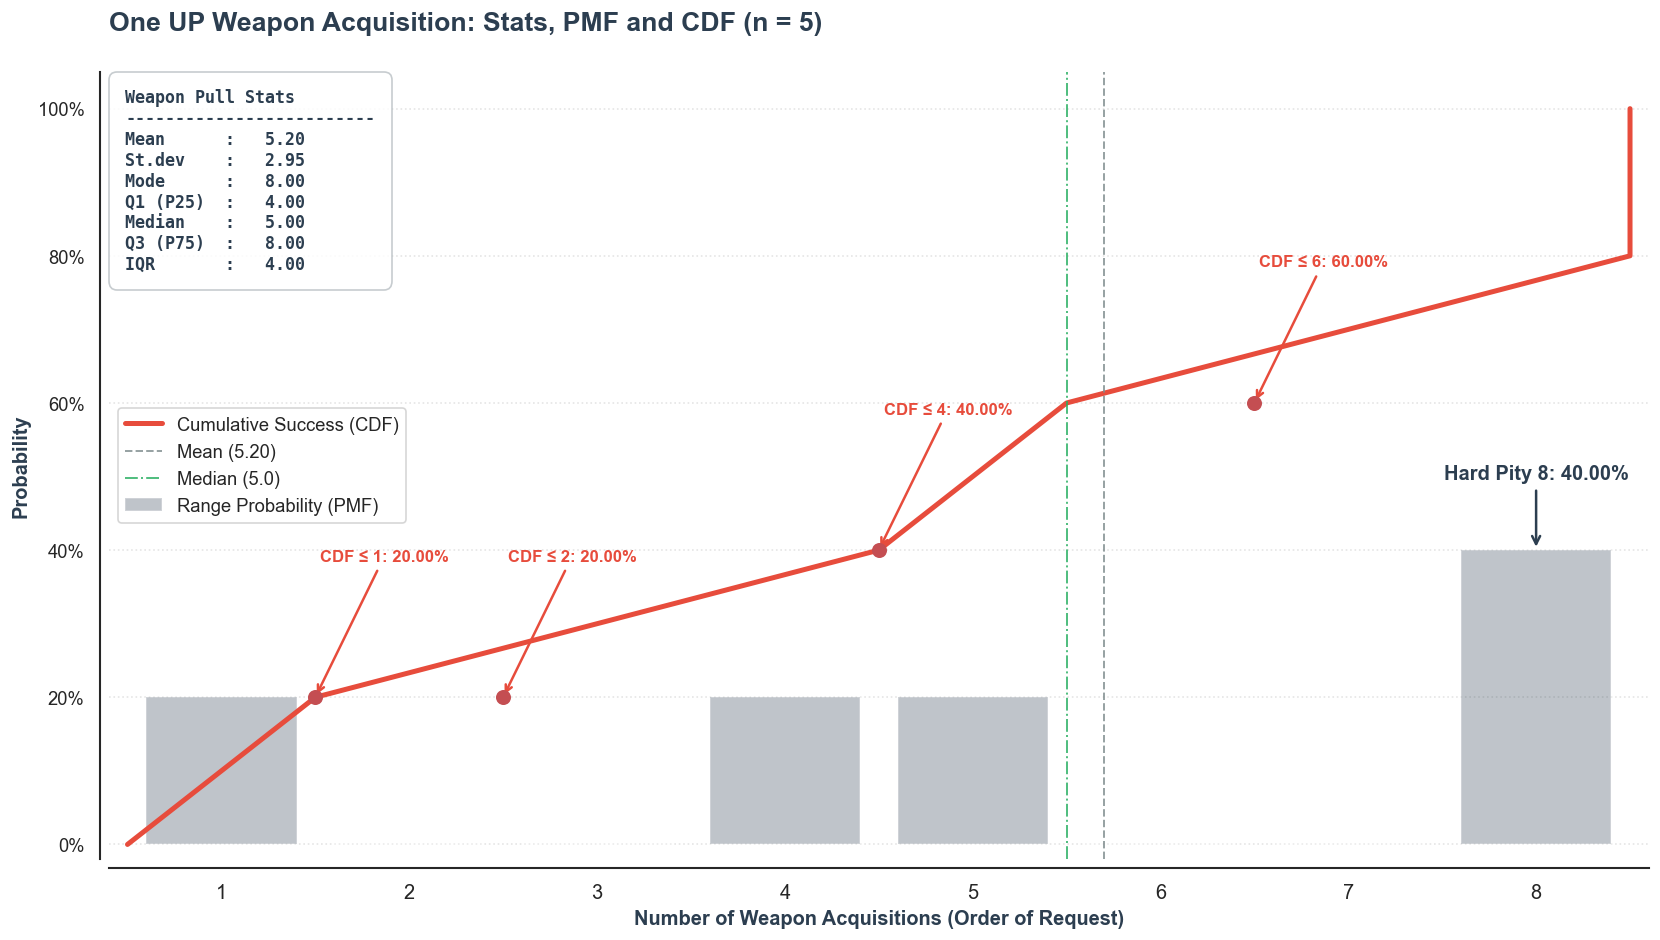

In [40]:
# =========================================================================
# 1. Load Weapon Simulated Production Data
# =========================================================================
single_weapon_path = DATA_DIR / 'sim_weapon_single.csv'
df_weapon = pd.read_csv(single_weapon_path)
pulls_data = df_weapon['num_pulls_for_weapon']
trials = len(pulls_data)

# Define discrete boundaries to isolate the final 8th weapon acquisition
bins = [0, 1, 2, 3, 4, 5, 6, 7, 8]

# Build custom labels matching the discrete bins (1, 2, ..., 7, 8)
labels = []
for i in range(len(bins)-1):
    if bins[i+1] == 8:
        labels.append("8")  # Isolated hard pity weapon wall
    else:
        labels.append(f"{bins[i+1]}")

# Categorize data into corresponding discrete acquisitions using pd.cut
df_weapon['range_cat'] = pd.cut(pulls_data, bins=bins, labels=labels)

# Calculate percentage for each single acquisition entry (PMF)
pmf_values = df_weapon['range_cat'].value_counts(normalize=True).sort_index() * 100

# =========================================================================
# 2. Plotting Settings (All-in-One Layout Synchronization)
# =========================================================================
fig, ax = plt.subplots(figsize=(14, 8))
x_pos = np.arange(len(labels))

# 2.1 PMF Bar Chart (Represents single entry acquisition probability)
ax.bar(x_pos, pmf_values, color=COLOR_PMF, alpha=0.3, edgecolor='white', linewidth=1, label='Range Probability (PMF)')

# 2.2 CDF Cumulative Curve with Non-uniform Axis Mapping (Using Interpolation)
sorted_data = np.sort(pulls_data)
cdf_x_raw = np.insert(sorted_data, 0, 0)
cdf_y_raw = np.insert(np.arange(1, len(sorted_data) + 1) / float(len(sorted_data)) * 100, 0, 0)

# Build a mapping anchor table to translate real weapon acquisitions to categorical x-coordinates
xp_anchors = np.array(bins)
fp_anchors = np.arange(len(bins)) - 0.5

# Perform linear interpolation to get a perfectly aligned CDF curve
cdf_x_mapped = np.interp(cdf_x_raw, xp_anchors, fp_anchors)
ax.plot(cdf_x_mapped, cdf_y_raw, color=COLOR_CDF, linewidth=3, label='Cumulative Success (CDF)')

# 2.3 Professional Visual Anchors: Mean and Median Vlines
mean_val = pulls_data.mean()
median_val = pulls_data.median()

# Map Mean and Median dynamically using our discrete anchor system
mean_x_mapped = np.interp(mean_val, xp_anchors, fp_anchors)
median_x_mapped = np.interp(median_val, xp_anchors, fp_anchors)

ax.axvline(mean_x_mapped, color='#7f8c8d', linestyle='--', linewidth=1.2, alpha=0.8, label=f'Mean ({mean_val:.2f})')
ax.axvline(median_x_mapped, color='#27ae60', linestyle='-.', linewidth=1.2, alpha=0.8, label=f'Median ({median_val:.1f})')

# 2.4 Statistical Parameters (Top-Left Clean Box Alignment)
stats = {
    'Mean': mean_val,
    'St.dev': pulls_data.std(),
    'Mode': pulls_data.mode()[0],
    'Q1 (P25)': pulls_data.quantile(0.25),
    'Median': median_val,
    'Q3 (P75)': pulls_data.quantile(0.75),
    'IQR': pulls_data.quantile(0.75) - pulls_data.quantile(0.25)
}
stats_text = "\n".join([f"{k:10}: {v:>6.2f}" for k, v in stats.items()])
at = AnchoredText(f"Weapon Pull Stats\n{'-'*25}\n{stats_text}",
                  prop=dict(size=10, family='monospace', fontweight='bold', color='#2c3e50'), 
                  frameon=True, loc='upper left', pad=0.5)
at.patch.set_boxstyle("round,pad=0.5")
at.patch.set_edgecolor('#bdc3c7')
at.patch.set_alpha(0.85)
ax.add_artist(at)

# 2.5 Specific Annotations (Pinpointed to look at Weapon Mechanics)
# (1) PMF Annotation: Hard Pity at 8th weapon acquisition (Index 7)
target_idx_final = 7 
val_8 = pmf_values.iloc[target_idx_final]
ax.annotate(f'Hard Pity 8: {val_8:.2f}%', 
            xy=(target_idx_final, val_8), 
            xytext=(0, 40), textcoords="offset points", 
            arrowprops=dict(arrowstyle='->', color=COLOR_PMF, lw=1.5),
            ha='center', va='bottom', fontweight='bold', color=COLOR_PMF)

# (2) CDF Specific Key Annotations [1, 2, 4, 6] representing crucial milestones
cdf_targets = [1, 2, 4, 6]

for target in cdf_targets:
    cdf_val = (pulls_data <= target).mean() * 100
    
    # Map marker dots perfectly onto the curve using the interpolation map
    marker_x = np.interp(target, xp_anchors, fp_anchors)
    ax.plot(marker_x, cdf_val, 'ro', markersize=8, zorder=5)
    
    # Precise pixel-offset layout tailored for weapon distribution curve space
    # if target == 1:
    #     x_pt, y_pt = 40, -30
    #     ha_dir, va_dir = 'left', 'top'
    if target in cdf_targets:
        x_pt, y_pt = 80, 80
        ha_dir, va_dir = 'right', 'bottom'
    # else:  # Target 6
    #     x_pt, y_pt = 50, -40
    #     ha_dir, va_dir = 'left', 'top'
        
    ax.annotate(f'CDF ≤ {target}: {cdf_val:.2f}%', 
                xy=(marker_x, cdf_val), 
                xytext=(x_pt, y_pt), textcoords="offset points",
                arrowprops=dict(arrowstyle='->', color=COLOR_CDF, lw=1.5),
                fontweight='bold', color=COLOR_CDF, fontsize=10,
                ha=ha_dir, va=va_dir)

# 2.6 Formatting & Detail Optimization
plt.title(f'One UP Weapon Acquisition: Stats, PMF and CDF (n = {trials:,})', fontsize=16, fontweight='bold', loc='left', pad=25, color='#2c3e50')
ax.set_xlabel('Number of Weapon Acquisitions (Order of Request)', fontsize=12, fontweight='bold', color='#2c3e50')
ax.set_ylabel('Probability', fontsize=12, fontweight='bold', color='#2c3e50')

ax.set_ylim(-2, 105)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

# Set limits covering exactly all 8 discrete entries
ax.set_xlim(-0.6, len(labels) - 0.4) 

# Fixed legend location
ax.legend(loc='center left', frameon=True)

# Disable trim to maintain unbroken axis line on the bottom-left corner
sns.despine(offset=5, trim=False)

# Clean horizontal tick positioning without text rotation
ax.set_xticks(x_pos)
plt.xticks(x_pos, labels, rotation=0, fontsize=12, ha='center')

plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

## 滿潛機率提升武器模擬結果之統計與視覺化圖表

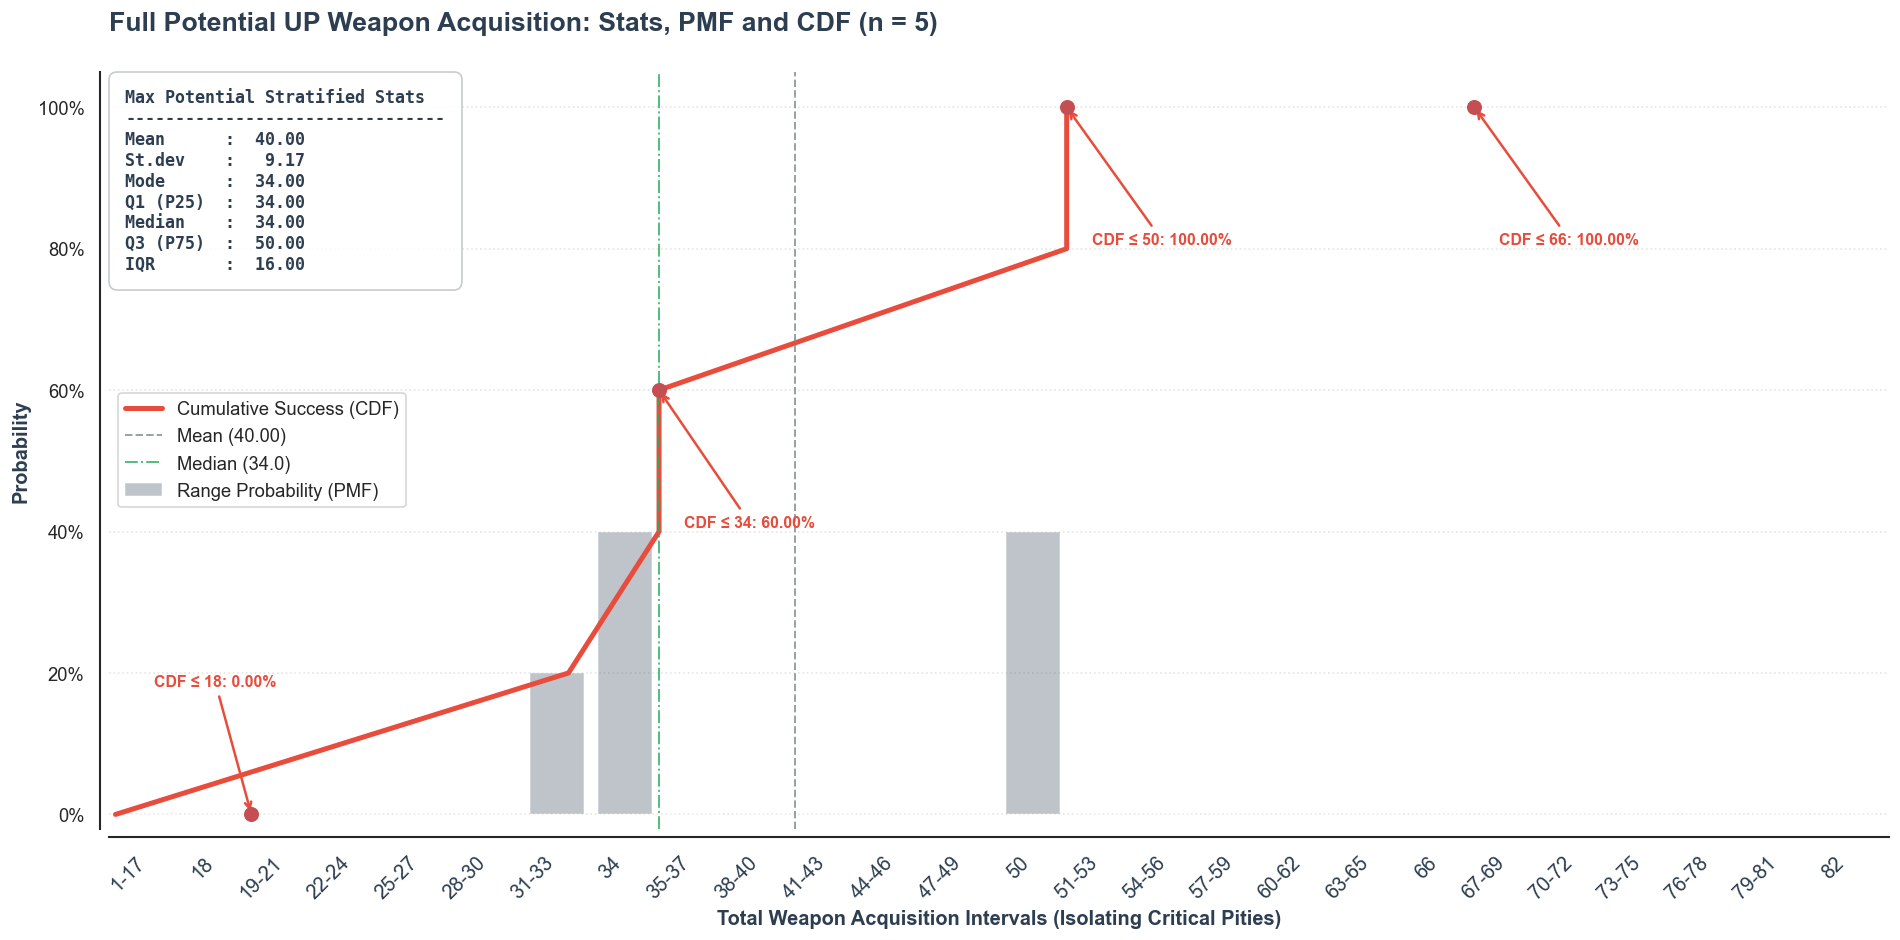

In [41]:
# =========================================================================
# 1. Load Weapon Simulated Production Data
# =========================================================================
FP_weapon_path = DATA_DIR / 'sim_weapon_full_potential.csv'
df_FPweapon = pd.read_csv(FP_weapon_path)
pulls_data = df_FPweapon['num_pulls_for_weapon']
trials = len(pulls_data)

# =========================================================================
# 2. Setup Non-Uniform Custom Bins (Grouping 3 pulls & Isolating Pity Walls)
# =========================================================================
# Define specialized custom boundaries isolating critical pity walls: 18, 34, 50, 66, 82
bins = [
    0, 17, 18, 21, 24, 27, 30, 33, 34, 37, 40, 43, 46, 49, 50, 
    53, 56, 59, 62, 65, 66, 69, 72, 75, 78, 81, 82
]

# Build custom text labels mapping the segmented structure
labels = []
for i in range(len(bins)-1):
    start = bins[i] + 1
    end = bins[i+1]
    if start == end:
        labels.append(f"{end}")  # Isolated milestones (18, 34, 50, 66, 82)
    else:
        labels.append(f"{start}-{end}")  # Combined 3-step range buckets

# Categorize into custom range segments using your variables
df_FPweapon['range_cat'] = pd.cut(pulls_data, bins=bins, labels=labels)
pmf_values = df_FPweapon['range_cat'].value_counts(normalize=True).sort_index() * 100

# =========================================================================
# 3. Plotting Layout (Non-Uniform Interval Mapping Engine)
# =========================================================================
fig, ax = plt.subplots(figsize=(16, 8))
x_pos = np.arange(len(labels))

# 3.1 PMF Segmented Bar Chart (Using your globally configured COLOR_PMF)
ax.bar(x_pos, pmf_values, color=COLOR_PMF, alpha=0.3, edgecolor='white', linewidth=1, label='Range Probability (PMF)')

# 3.2 CDF Interpolation Over Non-Uniform Grid Matrix
sorted_data = np.sort(pulls_data)
cdf_x_raw = np.insert(sorted_data, 0, 0)
cdf_y_raw = np.insert(np.arange(1, len(sorted_data) + 1) / float(len(sorted_data)) * 100, 0, 0)

xp_anchors = np.array(bins)
fp_anchors = np.arange(len(bins)) - 0.5
cdf_x_mapped = np.interp(cdf_x_raw, xp_anchors, fp_anchors)
ax.plot(cdf_x_mapped, cdf_y_raw, color=COLOR_CDF, linewidth=3, label='Cumulative Success (CDF)')

# 3.3 Visual Anchors Mapping Mean/Median onto Categorical Space
mean_val = pulls_data.mean()
median_val = pulls_data.median()

mean_x_mapped = np.interp(mean_val, xp_anchors, fp_anchors)
median_x_mapped = np.interp(median_val, xp_anchors, fp_anchors)

ax.axvline(mean_x_mapped, color='#7f8c8d', linestyle='--', linewidth=1.2, alpha=0.8, label=f'Mean ({mean_val:.2f})')
ax.axvline(median_x_mapped, color=PALETTE_QUANTILES[0], linestyle='-.', linewidth=1.2, alpha=0.8, label=f'Median ({median_val:.1f})')

# 3.4 Statistical Parameters Box Alignment (Using your custom stats layout)
stats = {
    'Mean': mean_val,
    'St.dev': pulls_data.std(),
    'Mode': pulls_data.mode()[0],
    'Q1 (P25)': pulls_data.quantile(0.25),
    'Median': median_val,
    'Q3 (P75)': pulls_data.quantile(0.75),
    'IQR': pulls_data.quantile(0.75) - pulls_data.quantile(0.25)
}
stats_text = "\n".join([f"{k:10}: {v:>6.2f}" for k, v in stats.items()])
at = AnchoredText(f"Max Potential Stratified Stats\n{'-'*32}\n{stats_text}",
                  prop=dict(size=10, family='monospace', fontweight='bold', color=COLOR_PMF), 
                  frameon=True, loc='upper left', pad=0.5)
at.patch.set_boxstyle("round,pad=0.5")
at.patch.set_edgecolor('#bdc3c7')
at.patch.set_alpha(0.85)
ax.add_artist(at)

# 3.5 Target Milestone Pinpoint Markings locked on [18, 34, 50, 66, 82]
cdf_targets = [18, 34, 50, 66]

for target in cdf_targets:
    cdf_val = (pulls_data <= target).mean() * 100
    marker_x = np.interp(target, xp_anchors, fp_anchors)
    ax.plot(marker_x, cdf_val, 'ro', markersize=8, zorder=5)
    
    # Custom pixel-offset layout based on the target location to avoid overlap
    if target == 18:
        x_pt, y_pt = 15, 75
        ha_dir, va_dir = 'right', 'bottom'
    else:
        x_pt, y_pt = 15, -75
        ha_dir, va_dir = 'left', 'top'
        
    ax.annotate(f'CDF ≤ {target}: {cdf_val:.2f}%', 
                xy=(marker_x, cdf_val), 
                xytext=(x_pt, y_pt), textcoords="offset points",
                arrowprops=dict(arrowstyle='->', color=COLOR_CDF, lw=1.5),
                fontweight='bold', color=COLOR_CDF, fontsize=9.5,
                ha=ha_dir, va=va_dir)

# 3.6 Interface Details Configuration
plt.title(f'Full Potential UP Weapon Acquisition: Stats, PMF and CDF (n = {trials:,})', fontsize=16, fontweight='bold', loc='left', pad=25, color=COLOR_PMF)
ax.set_xlabel('Total Weapon Acquisition Intervals (Isolating Critical Pities)', fontsize=12, fontweight='bold', color=COLOR_PMF)
ax.set_ylabel('Probability', fontsize=12, fontweight='bold', color=COLOR_PMF)

ax.set_ylim(-2, 105)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlim(-0.6, len(labels) - 0.4) 
ax.legend(loc='center left', frameon=True)
sns.despine(offset=5, trim=False)

# Horizontal ticks formatting with a clean 45-degree tilt
ax.set_xticks(x_pos)
plt.xticks(x_pos, labels, rotation=45, fontsize=12, ha='right', color=COLOR_PMF)

plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()